## ***ANN***
- ***ANN can learn complex nonlinear relationships using multiple layers and nonlinear activation functions.***

---

#### ***ANN For Regression***


In [5]:
import pandas as pd

df = pd.read_csv('/content/powerplant.csv')
df.head()


,AT,V,AP,RH,PE
0,8.34,40.77,1010.84,90.01,480.48
1,23.64,58.49,1011.40,74.20,445.75
2,29.74,56.90,1007.15,41.91,438.76
3,19.07,49.69,1007.22,76.79,453.09
4,11.80,40.66,1017.13,97.20,464.43


In [6]:
### features
# AT => temperature
# V => vacuum
# AP => pressure
# RH => humidity

### OUtput
# PE => produced energy

In [7]:
df.isnull().sum()

,0
AT,0
V,0
AP,0
RH,0
PE,0


In [8]:
X = df.drop("PE",axis=1)
y = df["PE"]

In [9]:
X.sample(5)

,AT,V,AP,RH
7601,21.11,74.78,1009.71,84.35
6599,22.70,66.44,1011.19,68.36
8908,19.47,58.79,1016.80,87.26
3146,30.02,69.04,1009.68,56.01
5793,12.72,44.90,1007.60,71.80


In [10]:
## Train Test Split
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(
    X,y,test_size=0.3,random_state=42
)

In [12]:
X.shape

(9568, 4)

In [13]:
## Apply Standard Scaling
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [14]:
## Build Tensors
import torch
import torch.nn as nn

X_train_tensor = torch.tensor(X_train_scaled,dtype=torch.float32)
X_test_tensor = torch.tensor(X_test_scaled,dtype=torch.float32)

y_train_tensor = torch.tensor(y_train.values,dtype=torch.float32).view(-1,1)
y_test_tensor = torch.tensor(y_test.values,dtype=torch.float32).view(-1,1)

In [15]:
type(X_train_scaled)

numpy.ndarray

In [17]:
## Build TensorDataset & DataLoader
from torch.utils.data import TensorDataset,DataLoader

# make tensors
train_data = TensorDataset(X_train_tensor,y_train_tensor)
test_data = TensorDataset(X_test_tensor,y_test_tensor)

# loaD dataset
train_loader = DataLoader(train_data, batch_size=32, shuffle=True)
test_loader = DataLoader(test_data, batch_size=32)

In [22]:
## Build Our ANN
class ANN(nn.Module):
  def __init__(self):
    super(ANN,self).__init__()

    self.model = nn.Sequential(
        # 1st hidden layer
        nn.Linear(X_train.shape[1],6),
        nn.ReLU(),

        # 2nd hidden layer
        nn.Linear(6,6),
        nn.ReLU(),

        # output layer
        nn.Linear(6,1)
    )

  # Fixed indentation: forward is now a method of the class
  def forward(self,x):
    return self.model(x)

In [24]:
import torch.optim as optim
# Re-initializing the model to pick up the corrected ANN class definition
model = ANN()

# loss & optimizer
criterian = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [25]:
### Train the ANN
train_losses = []
val_losses = []

best_val_loss = float("inf")
epochs = 100

for epoch in range(epochs):
    model.train()
    running_loss = 0.0

    for xb, yb in train_loader:
        optimizer.zero_grad()
        outputs = model(xb)
        loss = criterian(outputs, yb)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()

    epoch_train_loss = running_loss / len(train_loader)
    train_losses.append(epoch_train_loss)

    ## Validation
    model.eval()
    running_val_loss = 0.0

    with torch.no_grad():
        for xb, yb in test_loader:
            outputs = model(xb)
            loss = criterian(outputs, yb)
            running_val_loss += loss.item()

    epoch_val_loss = running_val_loss / len(test_loader)
    val_losses.append(epoch_val_loss)

    if (epoch + 1) % 10 == 0 or epoch == 0:
        print(f"Epoch {epoch+1}/{epochs} | Train Loss: {epoch_train_loss:.4f} | Val Loss: {epoch_val_loss:.4f}")

    if epoch_val_loss < best_val_loss:
        best_val_loss = epoch_val_loss
        torch.save(model.state_dict(), "best_model.pt")

Epoch 1/100 | Train Loss: 206074.6538 | Val Loss: 204370.7010
Epoch 10/100 | Train Loss: 7907.7612 | Val Loss: 6646.7965
Epoch 20/100 | Train Loss: 154.9693 | Val Loss: 132.3656
Epoch 30/100 | Train Loss: 28.3917 | Val Loss: 26.8954
Epoch 40/100 | Train Loss: 22.1406 | Val Loss: 21.1284
Epoch 50/100 | Train Loss: 21.0563 | Val Loss: 19.9406
Epoch 60/100 | Train Loss: 20.6544 | Val Loss: 19.1989
Epoch 70/100 | Train Loss: 20.8605 | Val Loss: 19.5651
Epoch 80/100 | Train Loss: 20.5272 | Val Loss: 19.1095
Epoch 90/100 | Train Loss: 20.5465 | Val Loss: 19.2348
Epoch 100/100 | Train Loss: 20.5050 | Val Loss: 19.4304


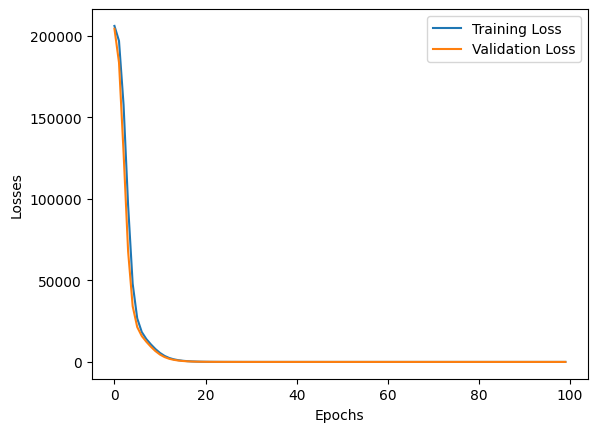

In [26]:
import matplotlib.pyplot as plt

loss_df = pd.DataFrame({
    "Training Loss": train_losses,
    "Validation Loss": val_losses
})

plt.plot(loss_df["Training Loss"], label = "Training Loss")
plt.plot(loss_df["Validation Loss"], label = "Validation Loss")

plt.xlabel("Epochs")
plt.ylabel("Losses")

plt.legend()

In [27]:
# Load Our Model
model.load_state_dict(torch.load("best_model.pt"))

<All keys matched successfully>

In [29]:
## Evaluation

model.eval()
with torch.no_grad():
    train_preds = model(X_train_tensor)
    test_preds = model(X_test_tensor)

    train_mse_loss = criterian(train_preds, y_train_tensor)
    test_mse_loss = criterian(test_preds, y_test_tensor)

print("Training MSE:", train_mse_loss.item())
print("Testing MSE:", test_mse_loss.item())

Training MSE: 20.15056610107422
Testing MSE: 19.023731231689453


In [30]:
from sklearn.metrics import r2_score
print("r^2 score =", r2_score(y_test, test_preds))

r^2 score = 0.933937814934362


In [31]:
predicted_df = pd.DataFrame(test_preds.numpy(), columns=["Predicted Values"])
actual_df = pd.DataFrame(y_test.values, columns=["Actual Values"])

pd.concat([predicted_df, actual_df], axis=1)

,Predicted Values,Actual Values
0,434.821533,433.27
1,436.376648,438.16
2,461.395142,458.42
3,476.568451,480.82
4,434.828247,441.41
...,...,...
2866,480.542480,480.31
2867,452.648499,446.77
2868,450.538177,454.66
2869,484.160187,483.77


In [43]:
X.columns

Index(['AREA', 'PERIMETER', 'MAJOR_AXIS', 'MINOR_AXIS', 'ECCENTRICITY',
       'EQDIASQ', 'SOLIDITY', 'CONVEX_AREA', 'EXTENT', 'ASPECT_RATIO',
       'ROUNDNESS', 'COMPACTNESS', 'SHAPEFACTOR_1', 'SHAPEFACTOR_2',
       'SHAPEFACTOR_3', 'SHAPEFACTOR_4', 'MeanRR', 'MeanRG', 'MeanRB',
       'StdDevRR', 'StdDevRG', 'StdDevRB', 'SkewRR', 'SkewRG', 'SkewRB',
       'KurtosisRR', 'KurtosisRG', 'KurtosisRB', 'EntropyRR', 'EntropyRG',
       'EntropyRB', 'ALLdaub4RR', 'ALLdaub4RG', 'ALLdaub4RB'],
      dtype='object')

#### ***ANN For Classification***

In [32]:
import pandas as pd

df = pd.read_csv('/content/datefruit.csv')
df.head()

,AREA,PERIMETER,MAJOR_AXIS,MINOR_AXIS,ECCENTRICITY,EQDIASQ,SOLIDITY,CONVEX_AREA,EXTENT,ASPECT_RATIO,...,KurtosisRR,KurtosisRG,KurtosisRB,EntropyRR,EntropyRG,EntropyRB,ALLdaub4RR,ALLdaub4RG,ALLdaub4RB,Class
0,422163,2378.908,837.8484,645.6693,0.6373,733.1539,0.9947,424428,0.7831,1.2976,...,3.2370,2.9574,4.2287,-59191263232,-50714214400,-39922372608,58.7255,54.9554,47.8400,BERHI
1,338136,2085.144,723.8198,595.2073,0.5690,656.1464,0.9974,339014,0.7795,1.2161,...,2.6228,2.6350,3.1704,-34233065472,-37462601728,-31477794816,50.0259,52.8168,47.8315,BERHI
2,526843,2647.394,940.7379,715.3638,0.6494,819.0222,0.9962,528876,0.7657,1.3150,...,3.7516,3.8611,4.7192,-93948354560,-74738221056,-60311207936,65.4772,59.2860,51.9378,BERHI
3,416063,2351.210,827.9804,645.2988,0.6266,727.8378,0.9948,418255,0.7759,1.2831,...,5.0401,8.6136,8.2618,-32074307584,-32060925952,-29575010304,43.3900,44.1259,41.1882,BERHI
4,347562,2160.354,763.9877,582.8359,0.6465,665.2291,0.9908,350797,0.7569,1.3108,...,2.7016,2.9761,4.4146,-39980974080,-35980042240,-25593278464,52.7743,50.9080,42.6666,BERHI


In [33]:
df.shape

(898, 35)

In [34]:
X = df.drop("Class",axis=1)
y = df["Class"]

In [36]:
unique = df["Class"].unique()
pd.DataFrame(unique)

,0
0,BERHI
1,DEGLET
2,DOKOL
3,IRAQI
4,ROTANA
5,SAFAVI
6,SOGAY


In [37]:
## Label Encoding
from sklearn.preprocessing import StandardScaler,LabelEncoder

le = LabelEncoder()
y = le.fit_transform(y)

## Train Test Split
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(
    X,y,test_size=0.2,random_state=42
)

In [38]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [46]:
## Build Our ANN Model
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader,TensorDataset


## Make Tensors
X_train_tensor = torch.tensor(X_train_scaled,dtype=torch.float32)
X_test_tensor = torch.tensor(X_test_scaled,dtype=torch.float32)

y_train_tensor = torch.tensor(y_train,dtype=torch.long)
y_test_tensor = torch.tensor(y_test,dtype=torch.long)

In [48]:
## Load Tensor Dataset
train_data= TensorDataset(X_train_tensor, y_train_tensor)
test_data = TensorDataset(X_test_tensor, y_test_tensor)

train_loader = DataLoader(train_data,batch_size=32, shuffle=True)
test_loader = DataLoader(test_data, batch_size=32)

In [49]:
## Build Our ANN
class ANN(nn.Module):
    def __init__(self):
        super(ANN, self).__init__()

        self.model = nn.Sequential(

            nn.Linear(X.shape[1], 64),
            nn.ReLU(),

            nn.Linear(64, 64),
            nn.ReLU(),

            nn.Linear(64, 7)
        )

    def forward(self, x):
        return self.model(x)

In [50]:
model = ANN()

# loss & optim
criteria = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters())


## Training the NN
epochs = 100
for epoch in range(epochs):
    model.train()
    running_loss = 0.0

    for xb, yb in train_loader:
        optimizer.zero_grad()
        outputs = model(xb)

        loss = criteria(outputs, yb)
        loss.backward()
        optimizer.step() # params update

        running_loss += loss.item()
    train_loss = running_loss / len(train_loader)

    print(f"epoch:{epoch+1}/{epochs}, loss:{train_loss}")

epoch:1/100, loss:1.7771826878837917
epoch:2/100, loss:1.1406306468922158
epoch:3/100, loss:0.7071127606474835
epoch:4/100, loss:0.538835971251778
epoch:5/100, loss:0.4642656691696333
epoch:6/100, loss:0.40845584610234137
epoch:7/100, loss:0.3706956570563109
epoch:8/100, loss:0.32874640498472296
epoch:9/100, loss:0.29669298685115314
epoch:10/100, loss:0.2676921976001366
epoch:11/100, loss:0.2591324691539225
epoch:12/100, loss:0.2284196424095527
epoch:13/100, loss:0.22310540306827295
epoch:14/100, loss:0.21092207826997922
epoch:15/100, loss:0.20221784743277924
epoch:16/100, loss:0.1916134989132052
epoch:17/100, loss:0.18979155984909638
epoch:18/100, loss:0.17353534585107927
epoch:19/100, loss:0.16844920004191605
epoch:20/100, loss:0.16302360756241757
epoch:21/100, loss:0.16692762757125107
epoch:22/100, loss:0.14635449777478757
epoch:23/100, loss:0.14486605512059253
epoch:24/100, loss:0.14435216646803462
epoch:25/100, loss:0.15050873127968414
epoch:26/100, loss:0.1358516245432522
epoch:2

In [51]:
## Evaluate Our Model
model.eval()

total = 0
correct = 0

with torch.no_grad():
    for xb, yb in test_loader:
        outputs = model(xb) # [0.2, 0.5, 1.3, -0.5, ..] - 7 vals
        _, predicted = torch.max(outputs, 1)

        correct += (predicted == yb).sum().item()
        total += yb.size(0) # actual samples in each batch

print("accuracy: ", correct/total * 100)

accuracy:  95.0


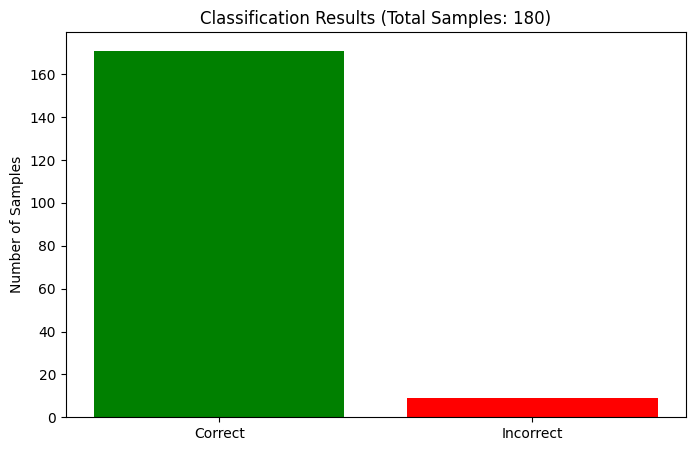

Final Accuracy: 95.00%


In [53]:
import matplotlib.pyplot as plt

labels = ['Correct', 'Incorrect']
values = [correct, total - correct]

plt.figure(figsize=(8, 5))
plt.bar(labels, values, color=['green', 'red'])
plt.title(f'Classification Results (Total Samples: {total})')
plt.ylabel('Number of Samples')
plt.show()

print(f"Final Accuracy: {(correct/total)*100:.2f}%")

In [54]:
torch.save(model.state_dict(), "ann_classification.pt")

In [1]:
# Index(['AREA', 'PERIMETER', 'MAJOR_AXIS', 'MINOR_AXIS', 'ECCENTRICITY',
#        'EQDIASQ', 'SOLIDITY', 'CONVEX_AREA', 'EXTENT', 'ASPECT_RATIO',
#        'ROUNDNESS', 'COMPACTNESS', 'SHAPEFACTOR_1', 'SHAPEFACTOR_2',
#        'SHAPEFACTOR_3', 'SHAPEFACTOR_4', 'MeanRR', 'MeanRG', 'MeanRB',
#        'StdDevRR', 'StdDevRG', 'StdDevRB', 'SkewRR', 'SkewRG', 'SkewRB',
#        'KurtosisRR', 'KurtosisRG', 'KurtosisRB', 'EntropyRR', 'EntropyRG',
#        'EntropyRB', 'ALLdaub4RR', 'ALLdaub4RG', 'ALLdaub4RB'],
#       dtype='object')